https://github.com/jgehrcke/covid-19-germany-gae/blame/master/cases-rki-by-ags.csv

data saved in same folder as other survstat data

## dataprocessing

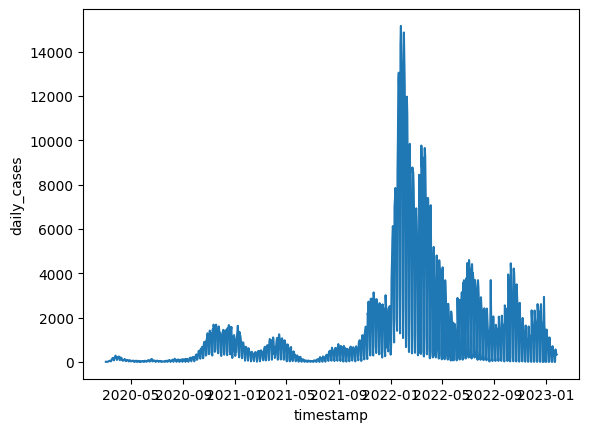

In [1]:
from src.utils import get_data_env
import os 
import pandas as pd
from itertools import product

raw_data = pd.read_csv(os.path.join(get_data_env(),'raw/cases-rki-by-ags.csv'))
raw_data['timestamp'] =  pd.to_datetime(raw_data['time_iso8601']).dt.date
raw_data.drop(columns = ['time_iso8601'], inplace = True)

raw_data_long           =  raw_data.melt(id_vars = 'timestamp', var_name='nuts3', value_name='cases')
raw_data_long['nuts3']  = raw_data_long['nuts3'].str.zfill(5)

# one error in nuts3: 16056 has become part of 16063
raw_data_long.loc[raw_data_long['nuts3'] == '16056', 'nuts3'] = '16063'

# Filter out unwanted nuts3 codes FIRST
filter_nuts = ['11001','11002','11003','11004','11005','11006','11007','11008','11009','11010','11011','11012','sum_cases']
raw_data_long = raw_data_long[~raw_data_long['nuts3'].isin(filter_nuts)]

# Group by timestamp and nuts3
raw_data_long = raw_data_long.groupby(['timestamp','nuts3'])['cases'].sum().reset_index(drop = False)

# NOW create complete index with only the remaining nuts3 codes
all_timestamps = raw_data_long['timestamp'].unique()
all_nuts3 = raw_data_long['nuts3'].unique()

complete_index = pd.DataFrame(
    list(product(all_timestamps, all_nuts3)),
    columns=['timestamp', 'nuts3']
)

# Merge to find missing combinations and fill with 0
raw_data_long = complete_index.merge(
    raw_data_long, 
    on=['timestamp', 'nuts3'], 
    how='left'
)
raw_data_long['cases'] = raw_data_long['cases'].fillna(0)

# Continue with processing
df = raw_data_long.sort_values(['nuts3', 'timestamp'])

df['daily_cases'] = df.groupby('nuts3')['cases'].diff()
df.loc[df['daily_cases'] < 0, 'daily_cases'] = 0
import seaborn as sns
df['timestamp'] = pd.to_datetime(df['timestamp'])
sns.lineplot(df[df['nuts3'] == '11000'], x = 'timestamp', y = 'daily_cases')

preprocessed_data = df[['timestamp','nuts3','daily_cases']].rename(columns = {'daily_cases':'cases','nuts3':'kz_kreis'})
iso = df['timestamp'].dt.isocalendar()

preprocessed_data['year'] = iso.year
preprocessed_data['week'] = iso.week
preprocessed_data['day'] = iso.day

preprocessed_data.loc[preprocessed_data['cases'].isna(), 'cases'] = 0
preprocessed_data.reset_index(drop = True, inplace=True)
preprocessed_data = preprocessed_data[['week','kz_kreis','cases','year','timestamp','day']]
preprocessed_data.to_csv(os.path.join(get_data_env(),'processed/germany/epidemiology/casedata/survstat/covid_daily.csv'), index=False)

## dataloading

In [1]:
from dataclasses import dataclass, field
from typing import Literal, Optional, Tuple, List
from pathlib import Path
import pandas as pd

from src.utils.textformatting import warning_emoji
from src.utils.exceptions import WissdatenMountingError

@dataclass
class EpiConfig:
    """ 
    Highly standardized configuration dataclass to be fed into the DataOrchestrator.
    The str function is very very detailed.
    
    Parameters
    ----------
    # ============= REQUIRED =============
    disease:                str
    data_env_dir:           str

    the rest is optional
    
    # ============= DATES =============
    date_range:             Tuple[str, str] = ('2001-01-01', '2025-01-01')
    
    # ============= GEOGRAPHY =============
    nuts_level:             Literal['nuts1', 'nuts2', 'nuts3'] = 'nuts3'
    split_berlin:           bool = True
    
    # ============= TASK CONFIG =============
    horizon_size:           int = 1
    horizon_leadtime:       int = 1
    sequence_length:        int = 1
    lag_num:                int = 1
    prediction_mode: Literal['regression','classification'] = 'regression'
    
    # ============= FEATURES =============
    include_population:     bool = False
    include_gisd:           bool = False    
    lag_column              str  = 'incidence
    time_index:             bool = True
    log_transform:          Optional[List[str]] = None
    log_shift:              float = 1.0    
    
    # ============= NORMALIZATION =============
    normalization_method:   Literal['minmax', 'zscore', 'none'] = 'zscore'

    
    # ============= SPLITTING =============
    split_trainval:         str = '2018-06-01'
    split_valtest:          str = '2019-06-01'
        

    # ============= COLUMN NAMES =============
    temporal_column:        str = 'timestamp'
    target_column:          str = 'incidence'
    id_column:              str = 'node'
    pred_column:            str = 'pred'
    
    # ============= OTHER =============
    incidence_scalar:       int = 10_000    
    verbose:                Literal[0,1,2] = 0 (higher is more output)

    Downstream:
    ----------
    Based on this configuration dataclass, the DataOrchestrator prepares a dataset.

    Examples:
    --------
    >>> config = EpiConfig(
    >>>     disease='influenza',
    >>>     data_env_dir=get_data_env(),
    >>>     date_range=('2017-05-15', '2019-06-01'),
    >>>     horizon_size=2,
    >>>     sequence_length=1,
    >>>     horizon_leadtime=3,
    >>>     lag_num=1,
    >>>     nuts_level='nuts3',
    >>>     log_transform=['incidence'],
    >>>     split_berlin=False,
    >>>     include_population=True
    >>> )    
    """


    # ============= REQUIRED =============
    disease:                str
    data_env_dir:           str
    
    # ============= DATES =============
    date_range:             Tuple[str, str] = ('2001-01-01', '2025-01-01')
    
    # ============= GEOGRAPHY =============
    nuts_level:             Literal['nuts1', 'nuts2', 'nuts3'] = 'nuts3'
    split_berlin:           bool = True
    
    # ============= TASK CONFIG =============
    horizon_size:           int = 1
    horizon_leadtime:       int = 1
    sequence_length:        int = 1
    lag_num:                int = 1
    prediction_mode:        Literal['regression','classification'] = 'regression'
    
    # ============= FEATURES =============
    include_population:     bool = False
    include_gisd:           bool = False
    time_index:             bool = True
    lag_column:             str  = 'incidence'
    log_transform:          Optional[List[str]] = None
    log_shift:              float = 1.0    
    
    # ============= NORMALIZATION =============
    normalization_method:   Literal['minmax', 'zscore', 'none'] = 'zscore'
    
    # ============= SPLITTING =============
    split_trainval:         str = '2018-06-01'
    split_valtest:          str = '2019-06-01'
        

    # ============= COLUMN NAMES =============
    temporal_column:        str = 'timestamp'
    target_column:          str = 'incidence'
    id_column:              str = 'node'
    pred_column:            str = 'pred'
    
    # ============= OTHER =============
    incidence_scalar:       int = 10_000    
    verbose:                Literal[0,1,2] = 0

    def __post_init__(self):
        """Validate configuration after initialization."""
        # Convert dates to timestamps
        self._min_date          = pd.to_datetime(self.date_range[0])
        self._max_date          = pd.to_datetime(self.date_range[1])
        self._split_trainval    = pd.to_datetime(self.split_trainval)
        self._split_valtest     = pd.to_datetime(self.split_valtest)

        if self._min_date >= self._max_date:
            raise ValueError(f"min_date ({self._min_date.date()}) must be before max_date ({self._max_date.date()})")
        
        if self._split_trainval >= self._split_valtest:
            raise ValueError(f"split_trainval must be before split_valtest")
        
        if not (self._min_date <= self._split_trainval < self._split_valtest <= self._max_date):
            raise ValueError(f"Splits must be within date range")
        
        # Validate horizon config
        if self.horizon_size < 1:
            raise ValueError(f"horizon_size must be >= 1, got {self.horizon_size}")
        if self.horizon_leadtime < 1:
            raise ValueError(f"horizon_leadtime must be >= 1, got {self.horizon_leadtime}")
        if self.sequence_length < 1:
            raise ValueError(f"sequence_length must be >= 1, got {self.sequence_length}")
        if self.lag_num < 1:
            raise ValueError(f"number of lags must be >= 1, got {self.lag_num}")            
        
        # validate task
        if self.target_column == 'incidence' and self.prediction_mode == 'classification':
            raise ValueError(f'Invalid combination of target as incidence and prediction mode as classification. Please adjust')

        # Validate input
        self._validate_datapaths()
        self._validate_current_limitations()

    # ============= VALIDATION FUNCTIONS ==============
    def _validate_datapaths(self):
        """Validates data paths and Wissdatenmounting"""

        if not Path(self.data_env_dir).exists():
            raise WissdatenMountingError(self.data_env_dir)

        path_checks = [
            ("Disease data",            self.get_disease_path),
            ("Population data",         self.get_population_path),
            ("Shape data",              self.get_shapefile_path),
            ("Nuts names",              self.get_nuts_names_path),
            ("Berlin population data",  self.get_population_berlin_districts_path),
        ]
        for name, path_func in path_checks:
            path = path_func()
            if not path.exists():
                raise FileNotFoundError(f"{name} not found: {path}")
            
    def _validate_current_limitations(self):
        if self.sequence_length > 1:
            print(f'{warning_emoji} Currently no sequence length implemented for shallow nor deep models, nor their respective loaders\nsequence length is set to 1')  
        self.sequence_length = 1    

    # ============= COMPUTED PROPERTIES =============
    @property
    def lookback_weeks(self) -> int:
        """Total weeks of data needed for sequence + horizon + leadtime."""
        return self.sequence_length + self.horizon_size + self.horizon_leadtime - 1
    
    @property
    def min_date(self) -> pd.Timestamp:
        """Original minimum date (user-specified)."""
        return self._min_date
    
    @property
    def max_date(self) -> pd.Timestamp:
        """Maximum date."""
        return self._max_date
    
    @property
    def min_date_extended(self) -> pd.Timestamp:
        """Extended minimum date accounting for lookback period."""
        return self._min_date - pd.Timedelta(weeks=self.lookback_weeks)
    
    @property
    def split_trainval_ts(self) -> pd.Timestamp:
        """Train/val split as timestamp."""
        return self._split_trainval
    
    @property
    def split_valtest_ts(self) -> pd.Timestamp:
        """Val/test split as timestamp."""
        return self._split_valtest
    
    @property
    def split_columns(self) -> list[str]:
        """Names of split indicator columns."""
        return ['train', 'val', 'test']
    
    @property
    def data_path(self) -> Path:
        """Path object for data directory."""
        return Path(self.data_env_dir)
    
    # ============== Paths returning ===================

    def get_disease_path(self) -> Path:
        """Path to disease CSV file."""
        return self.data_path / 'processed/germany/epidemiology/casedata/survstat' / f'{self.disease}.csv'
    
    def get_population_path(self) -> Path:
        """Path to population CSV file."""
        return self.data_path / 'processed/germany/sociodemography/population_size_03.csv'
    
    def get_population_berlin_districts_path(self) -> Path:
        """Path to berlin - districts population (2024) CSV file."""
        return self.data_path / 'processed/germany/sociodemography/population_size_berlin_districts_03.csv'    
    
    def get_shapefile_path(self) -> Path:
        """Path to shapefile."""
        return self.data_path / f'processed/germany/geospatial/shapefiles/shape_{self.nuts_level}.shp'
    
    def get_nuts_names_path(self) -> Path:
        """Path to NUTS names file."""
        return self.data_path / 'processed/germany/geospatial/harmonization/nuts.tsv'
    
    def get_gisd_path(self) -> Path:
        """Path to gisd data names file."""
        return self.data_path / f'processed/germany/sociodemography/gisd_{self.nuts_level}.csv'        
    
    # ============= SUMMARY METHODS =============
    
    def summary(self) -> str:
        """Return formatted summary of configuration."""
        return f"""
EpiConfig Summary:
==================
Disease:            {self.disease}
NUTS Level:         {self.nuts_level}
Date Range:         {self.min_date.date()} to {self.max_date.date()}
Extended Start:     {self.min_date_extended.date()} (lookback: {self.lookback_weeks} weeks)

Task Configuration:
-------------------
Horizon Size:       {self.horizon_size}
Horizon Leadtime:   {self.horizon_leadtime}
Sequence Length:    {self.sequence_length}

Features:
--------
lag_num:            {self.lag_num}
lag_column:         {self.lag_column}
time index:         {self.time_index}
population size:    {self.include_population}

Splits:
-------
Train/Val:          {self._split_trainval.date()}
Val/Test:           {self._split_valtest.date()}

Processing:
-----------
Normalization:      {self.normalization_method}
Log Transform:      {self.log_transform}
Split Berlin:       {self.split_berlin}
"""
    
    def __str__(self) -> str:
        return self.summary()
    
    def __repr__(self) -> str:
        return (f"EpiConfig(disease={self.disease!r}, "
                f"nuts_level={self.nuts_level!r}, "
                f"date_range={self.date_range!r}, "
                f"horizon_size={self.horizon_size}, "
                f"sequence_length={self.sequence_length})")


In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator, ShallowDataLoaderManager, GraphDataLoaderManager, DeepDataLoaderManager
from src.models import ConstantModel, PersistenceModel, ClimateologyModel, NodeLSTMModel, NodeGRUModel, GATv2Model, SpatialGNNModel

# get data
disease_name    = 'covid_daily'
nuts_level      = 'nuts3'
min_date        = '2020-03-02'
max_date        = '2023-01-01'
split_trainval  = '2022-01-01'
split_valtest   = '2022-03-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 5
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = disease_name,
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = split_berlin,
    include_population  = True,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'incidence',
    lag_column          = 'incidence',  
    verbose             = 0  
    )    

data_orchestrator = (DataOrchestrator(config)
                        .load_raw()
                        .harmonize_raw()
                        .process_data()
                        .build_features()
                        .normalize()
                        .finalize()
                        )

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23448540/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [2]:
data_orchestrator.data_context.tokenization_map['id_idx']['11000']

324

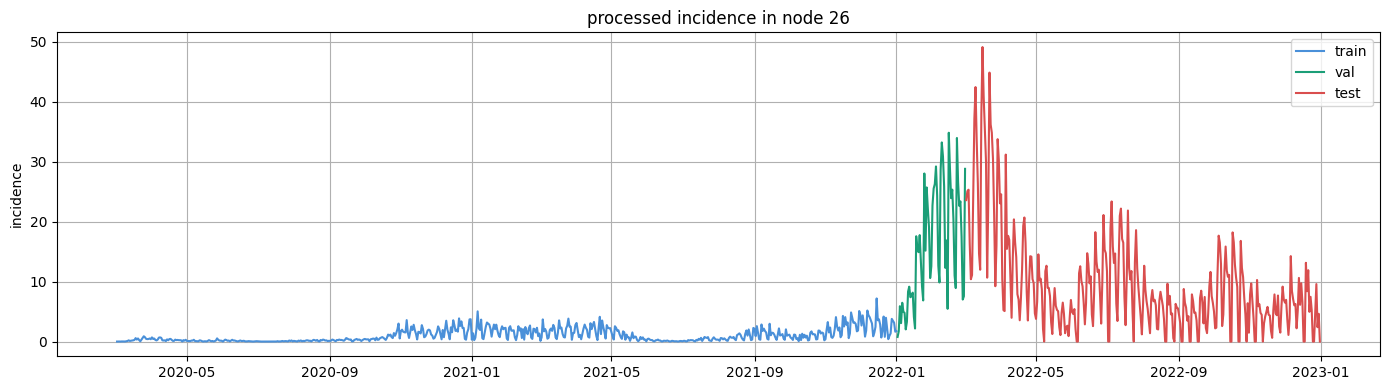

In [7]:
data_orchestrator.preview(26).show()

In [5]:
from src.dataloading import ShallowDataLoaderManager, GraphDataLoaderManager

In [6]:
from src.dataloading import ShallowDataLoaderManager
from src.models import PersistenceModel, ClimateologyModel

sl = ShallowDataLoaderManager(data_orchestrator).construct_dataloaders()
dl = DeepDataLoaderManager(data_orchestrator).construct_dataloaders()
gl = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()

ps = PersistenceModel(sl)
cm = ClimateologyModel(sl)

ps.forecast('test')
raw_f1 = ps.show_forecasts([26], 'test')

cm.forecast('test')
raw_f2 = cm.show_forecasts([26], 'test')

f1 = (raw_f1
      .labels.change_suptitle('Persistence model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','persistence model'])
      .change_figsize(10,5).legend.move('upper left'))

f2 = (raw_f2
      .labels.change_suptitle('Climateology model','bold',12)
      .labels.change_title('Predictions node 26: Hannover')
      .labels.change_xlab('time')
      .labels.change_ylab('incidence')
      .legend.set_labels(['true incidence','climateology model'])
      .change_figsize(10,5).legend.move('upper left'))


==                lstm_baseline                 ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: DeepData(x=(400, 6, 1), y=(400, 1))
Epoch 001 train loss: 0.8206, val loss: 7.3376 ✓ (new best)
Epoch 002 train loss: 0.5130, val loss: 4.9037 ✓ (new best)
Epoch 003 train loss: 0.4349, val loss: 4.5149 ✓ (new best)
Epoch 004 train loss: 0.4128, val loss: 4.1816 ✓ (new best)
Epoch 005 train loss: 0.3964, val loss: 3.9024 ✓ (new best)
Epoch 006 train loss: 0.3849, val loss: 3.6677 ✓ (new best)
Epoch 007 train loss: 0.3763, val loss: 3.4696 ✓ (new best)
Epoch 008 train loss: 0.3707, val loss: 3.2968 ✓ (new best)
Epoch 009 train loss: 0.3666, val loss: 3.1609 ✓ (new best)
Epoch 010 train loss: 0.3630, val loss: 3.0478 ✓ (new best)
Epoch 011 train loss: 0.3597, val loss: 2.9482 ✓ (new best)
Epoch 012 train loss: 0.3577, val loss: 2.8623 ✓ (new best)
Epoch 013 train loss: 0.3554, val loss: 2.7904 ✓ (new best)
Epoch 014 train loss: 0.3538, val loss: 2.7288 ✓ (new best)
Epoch 015 

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:237: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 049 train loss: 0.3000, val loss: 2.1143 (patience: 7/10)
lr has been updated from 1.00e-05 to 5.00e-06
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:00<00:00, 461.52it/s]


Test loss: 2.8383
forecasted ✓


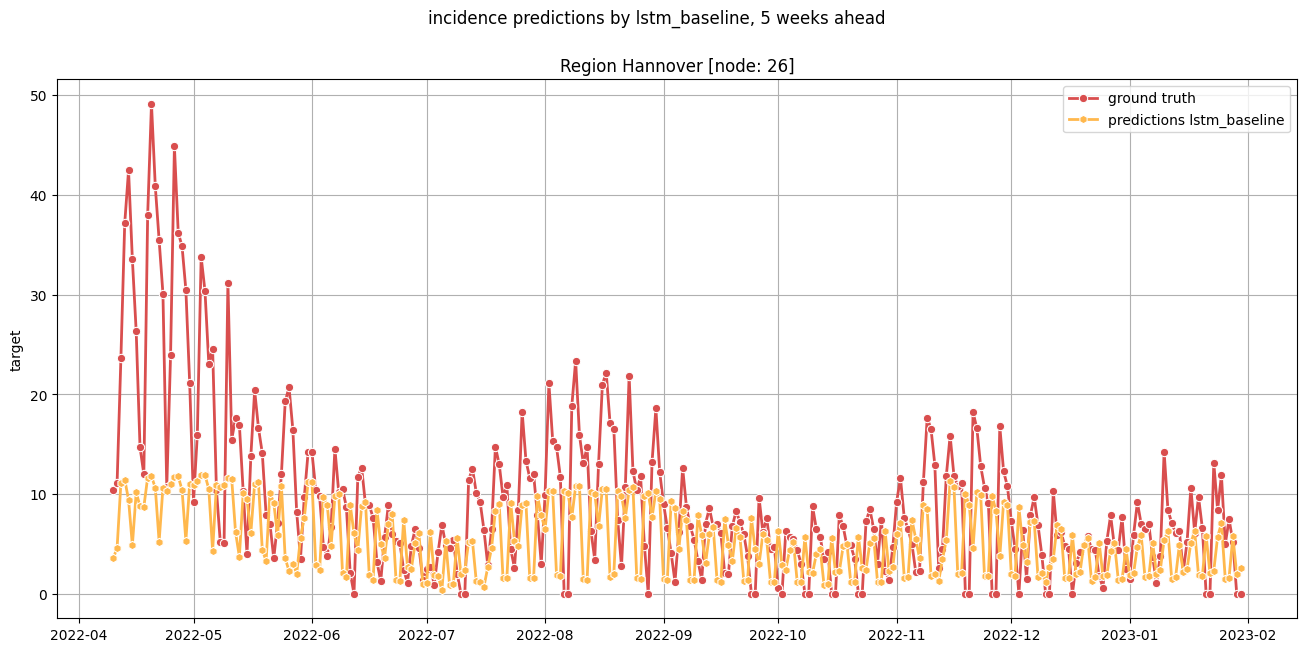

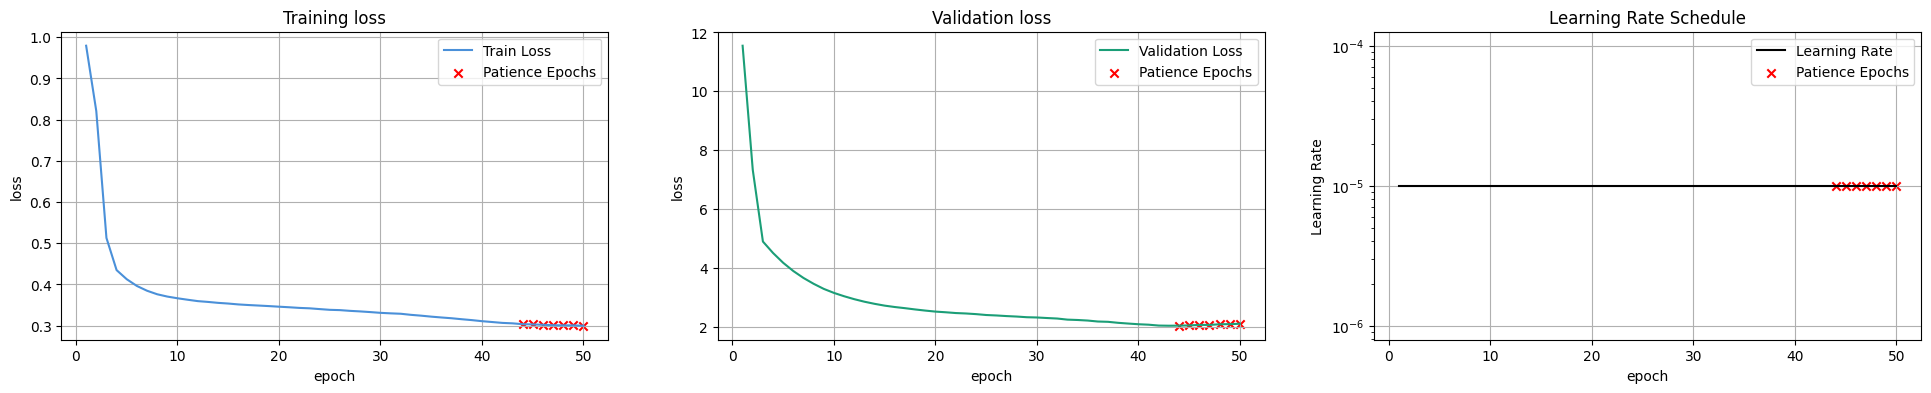

In [8]:
from src.models import NodeLSTMModel

lr = 0.00001
n_epochs= 50
min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

lstm = NodeLSTMModel(dl, verbose = 2)
lstm.set_model_hparams()
lstm.set_global_hparams(**global_hparams)
lstm.train()
lstm.forecast('test')
lstm.show_forecasts(26).show()


==                  spatialgnn                  ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 6, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.9605, val loss: 11.0313 ✓ (new best)
Epoch 002 train loss: 0.9262, val loss: 10.5259 ✓ (new best)
Epoch 003 train loss: 0.8875, val loss: 9.9676 ✓ (new best)
Epoch 004 train loss: 0.8437, val loss: 9.3635 ✓ (new best)
Epoch 005 train loss: 0.7951, val loss: 8.7178 ✓ (new best)
Epoch 006 train loss: 0.7430, val loss: 8.0405 ✓ (new best)
Epoch 007 train loss: 0.6911, val loss: 7.3616 ✓ (new best)
Epoch 008 train loss: 0.6392, val loss: 6.6956 ✓ (new best)
Epoch 009 train loss: 0.5907, val loss: 6.0666 ✓ (new best)
Epoch 010 train loss: 0.5454, val loss: 5.4907 ✓ (new best)
Epoch 011 train loss: 0.5079, val loss: 4.9793 ✓ (new best)
Epoch 012 train loss: 0.4768, val loss: 4.5480 ✓ (new best)
Epoch 013 train loss: 0.4543, val loss: 4.1912 ✓ (new best)
Epoch 014 train loss: 0.

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:237: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 049 train loss: 0.3332, val loss: 2.2260 ✓ (new best)
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:00<00:00, 637.40it/s]


Test loss: 3.1217
forecasted ✓


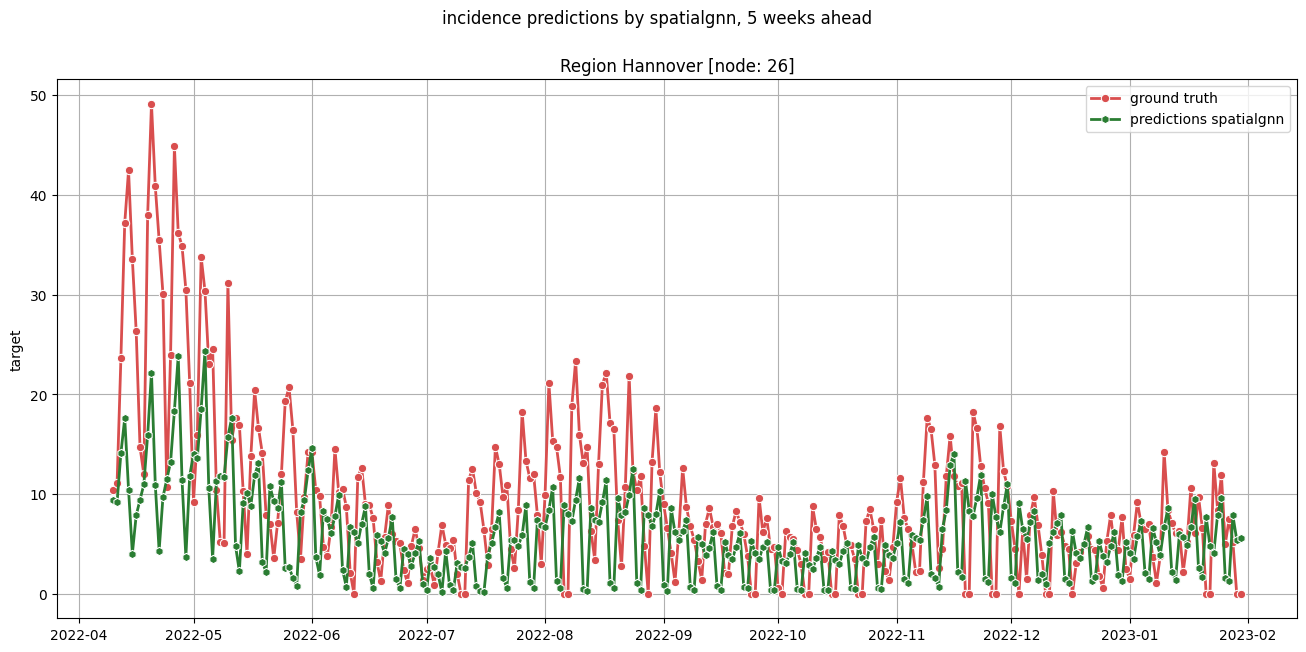

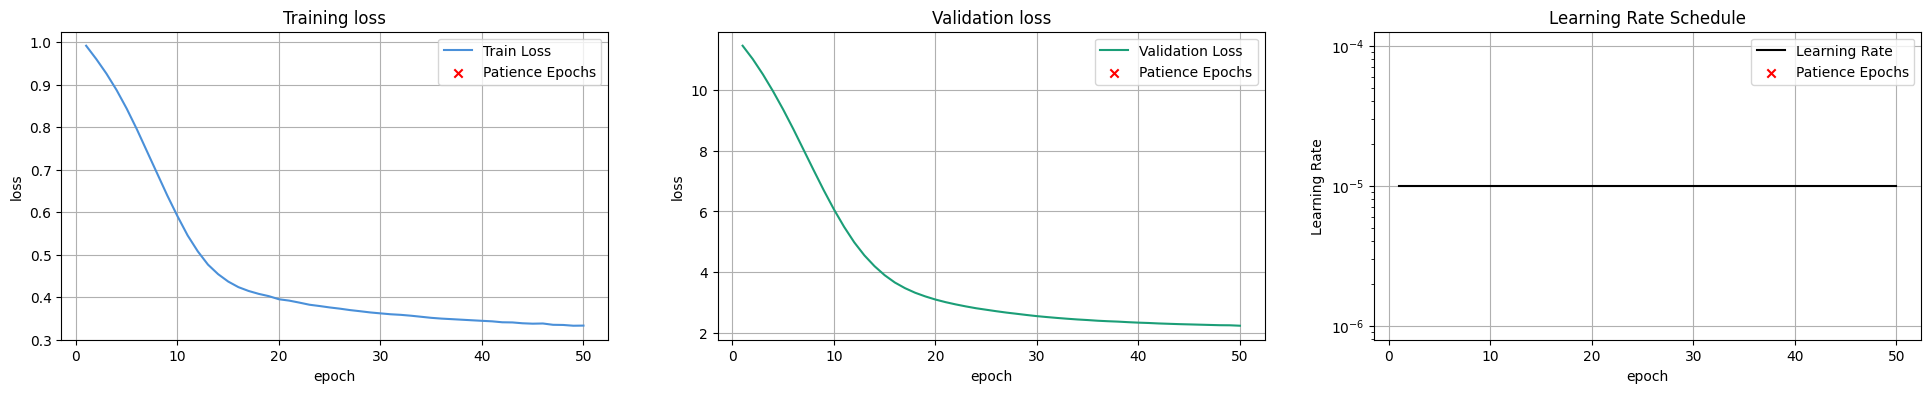

In [10]:
from src.models import SpatialGNNModel

lr = 0.00001
n_epochs= 50
min_delta = 0
loss = 'mse'

global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

gcn = SpatialGNNModel(gl, verbose = 2)
gcn.set_model_hparams()
gcn.set_global_hparams(**global_hparams)
gcn.train()
gcn.forecast('test')
gcn.show_forecasts(26).show()


==                  gatv2model                  ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 6, 1), y=(400, 1), edge_index=(2, 3905), edge_weight=(3905,))
Epoch 001 train loss: 0.5016, val loss: 4.7474 ✓ (new best)
Epoch 002 train loss: 0.3820, val loss: 3.4635 ✓ (new best)
Epoch 003 train loss: 0.3526, val loss: 3.0721 ✓ (new best)
Epoch 004 train loss: 0.3323, val loss: 2.8224 ✓ (new best)
Epoch 005 train loss: 0.3177, val loss: 2.5784 ✓ (new best)
Epoch 006 train loss: 0.3089, val loss: 2.4136 ✓ (new best)
Epoch 007 train loss: 0.3014, val loss: 2.3176 ✓ (new best)
Epoch 008 train loss: 0.2956, val loss: 2.2361 ✓ (new best)
Epoch 009 train loss: 0.2908, val loss: 2.1570 ✓ (new best)
Epoch 010 train loss: 0.2889, val loss: 2.1344 ✓ (new best)
Epoch 011 train loss: 0.2864, val loss: 2.0650 ✓ (new best)
Epoch 012 train loss: 0.2836, val loss: 2.0342 ✓ (new best)
Epoch 013 train loss: 0.2820, val loss: 2.0239 ✓ (new best)
Epoch 014 train loss: 0.28

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:237: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:00<00:00, 461.74it/s]


Test loss: 1.3744
forecasted ✓


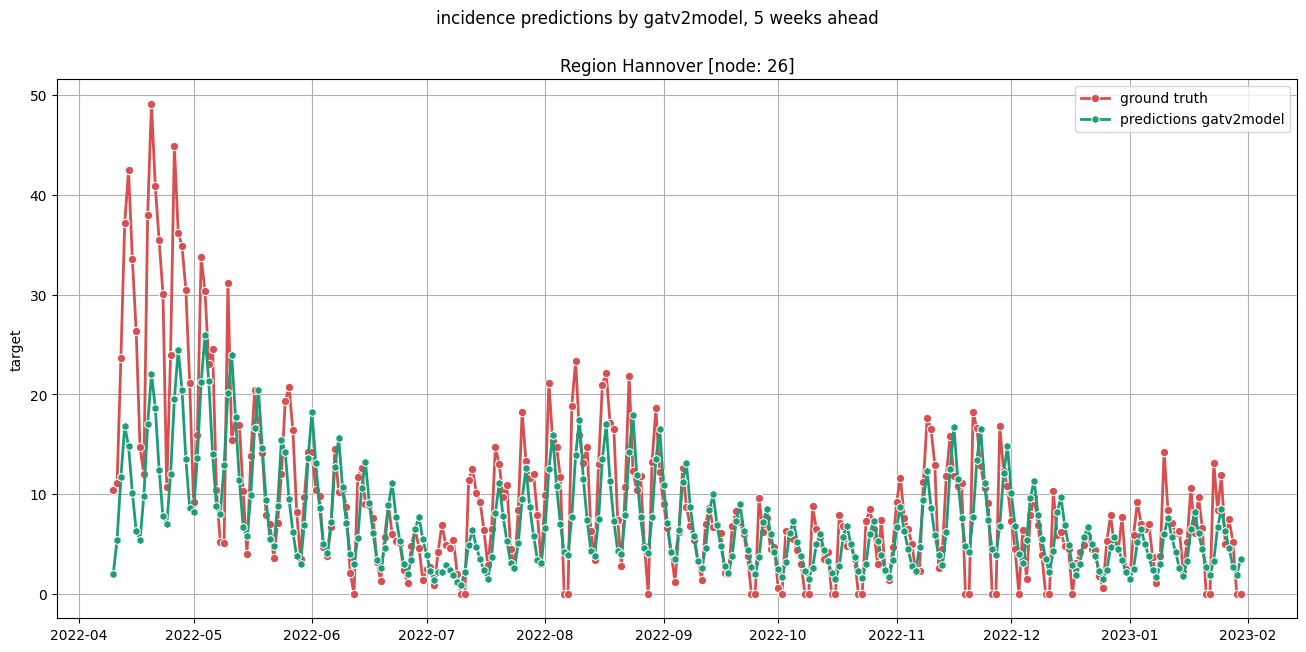

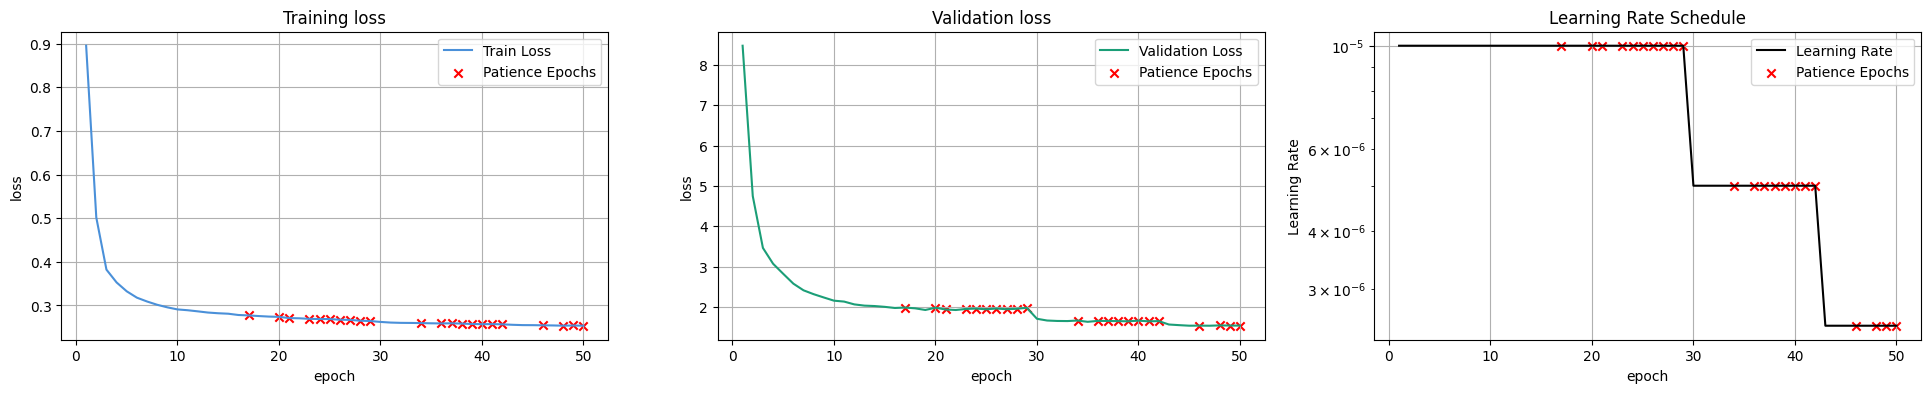

In [11]:
from src.models import GATv2Model

lr = 0.00001
# n_epochs= 250
min_delta = 0
loss = 'mse'

gl = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('static_commuter24_1').construct_dataloaders()


global_hparams = {
    "lr"                : lr,
    "n_epochs"          : n_epochs,
    "scheduler"         : 'plateau',
    "scheduler_kwargs"  :  {'mode': 'min', 'factor': 0.5, 'patience': 6},
    'min_delta'         : min_delta,
    'loss'              : loss,
    'patience'          : 10,
    }

gat = GATv2Model(gl, verbose = 2)
gat.set_model_hparams()
gat.set_global_hparams(**global_hparams)
gat.train()
gat.forecast('test')
gat.show_forecasts(26).show()

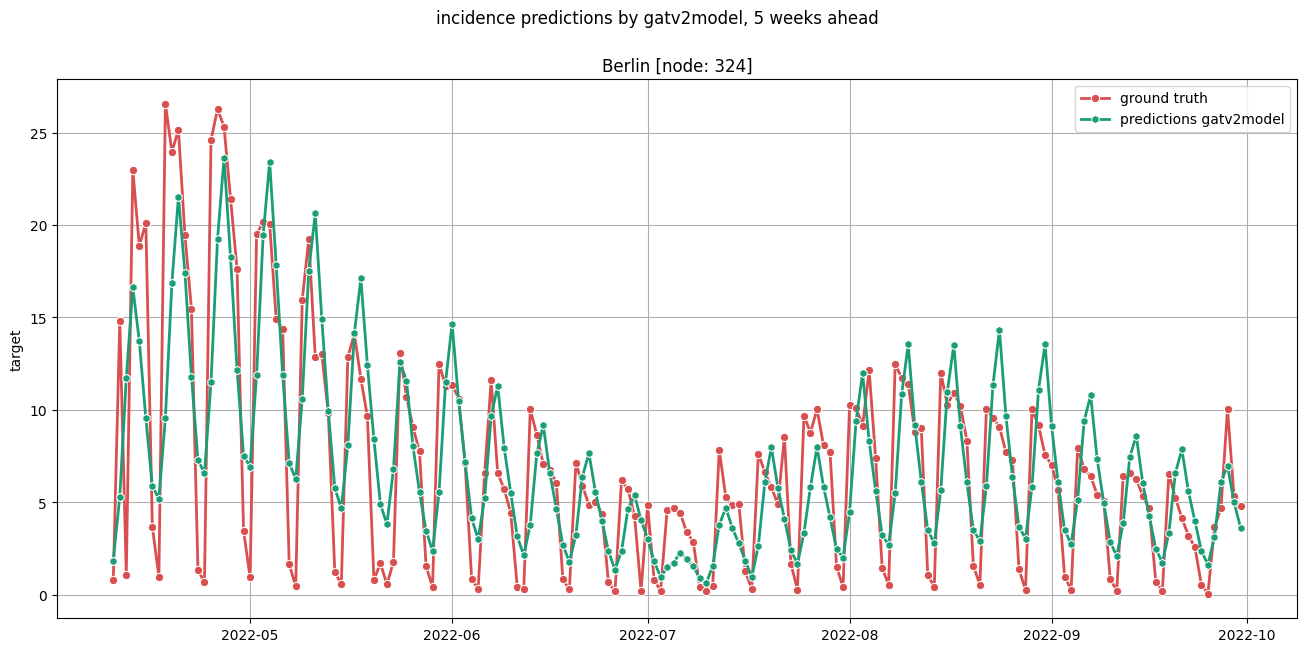

In [ ]:
gat.show_forecasts(324).show()


==                      gn                      ==
model_hparams_set ✓
global_hparams_set ✓
Dataloader Snapshot: GraphData(x=(400, 6, 1), y=(400, 1), edge_index=(2, 2488), edge_weight=(2488,))
Epoch 001 train loss: 0.4449, val loss: 4.1169 ✓ (new best)
Epoch 002 train loss: 0.3786, val loss: 3.4747 ✓ (new best)
Epoch 003 train loss: 0.3574, val loss: 3.2032 ✓ (new best)
Epoch 004 train loss: 0.3391, val loss: 2.9657 ✓ (new best)
Epoch 005 train loss: 0.3239, val loss: 2.7242 ✓ (new best)
Epoch 006 train loss: 0.3131, val loss: 2.5183 ✓ (new best)
Epoch 007 train loss: 0.3040, val loss: 2.3989 ✓ (new best)
Epoch 008 train loss: 0.2964, val loss: 2.2983 ✓ (new best)
Epoch 009 train loss: 0.2899, val loss: 2.2228 ✓ (new best)
Epoch 010 train loss: 0.2854, val loss: 2.1552 ✓ (new best)
Epoch 011 train loss: 0.2824, val loss: 2.1235 ✓ (new best)
Epoch 012 train loss: 0.2792, val loss: 2.0998 ✓ (new best)
Epoch 013 train loss: 0.2778, val loss: 2.0637 ✓ (new best)
Epoch 014 train loss: 0.27

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/models/deep/deepmodel.py:237: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Epoch 049 train loss: 0.2508, val loss: 1.8556 (patience: 2/10)
trained ✓


Forecasting test: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 296/296 [00:00<00:00, 466.80it/s]


Test loss: 1.3925
forecasted ✓


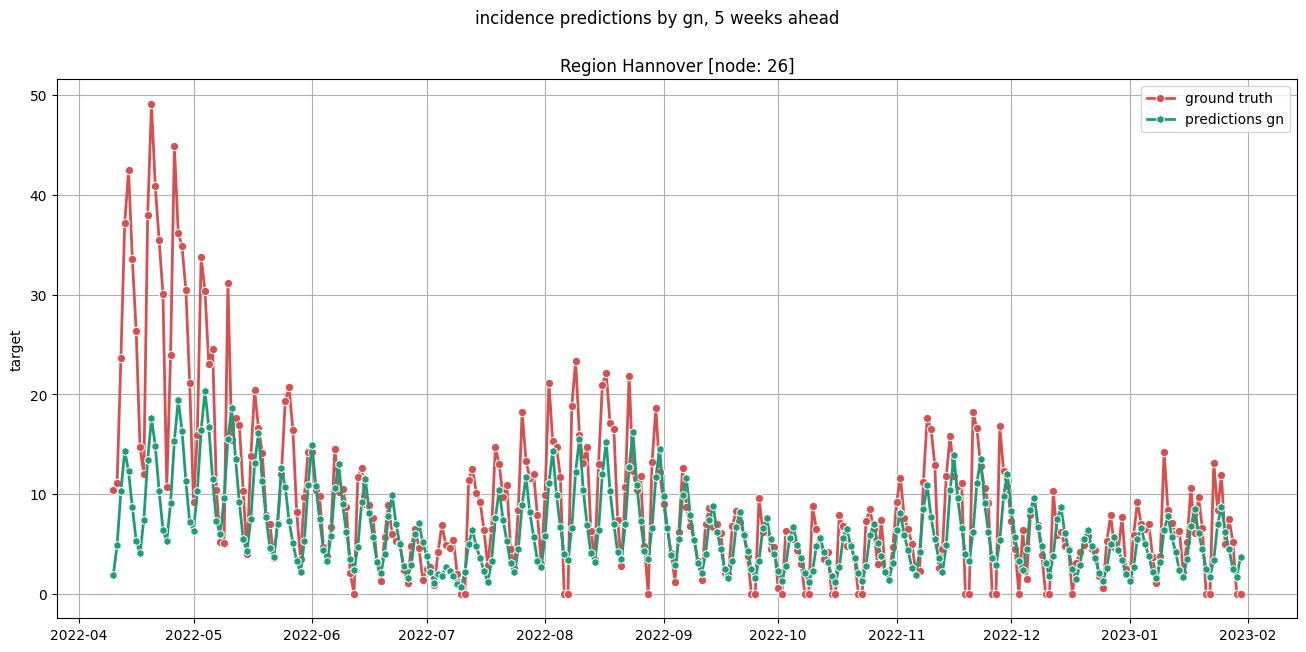

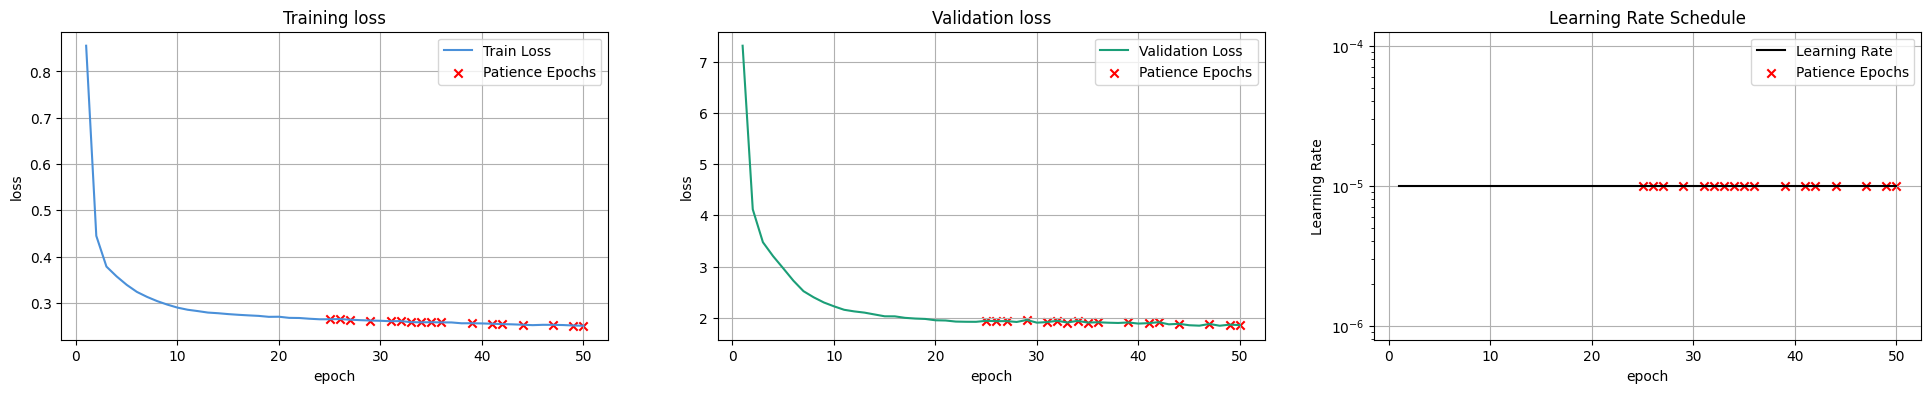

In [12]:
gl2 = GraphDataLoaderManager(data_orchestrator).retrieve_static_graph('geographical_neighbors1').construct_dataloaders()

gat2 = GATv2Model(gl2, verbose = 2, name = 'gn')
gat2.set_model_hparams()
gat2.set_global_hparams(**global_hparams)
gat2.train()
gat2.forecast('test')
gat2.show_forecasts(26).show()

computing metrics: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:05<00:00,  1.15it/s]
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center', fontsize=8)
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/evaluation/evaluationplotter.py:215: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. af

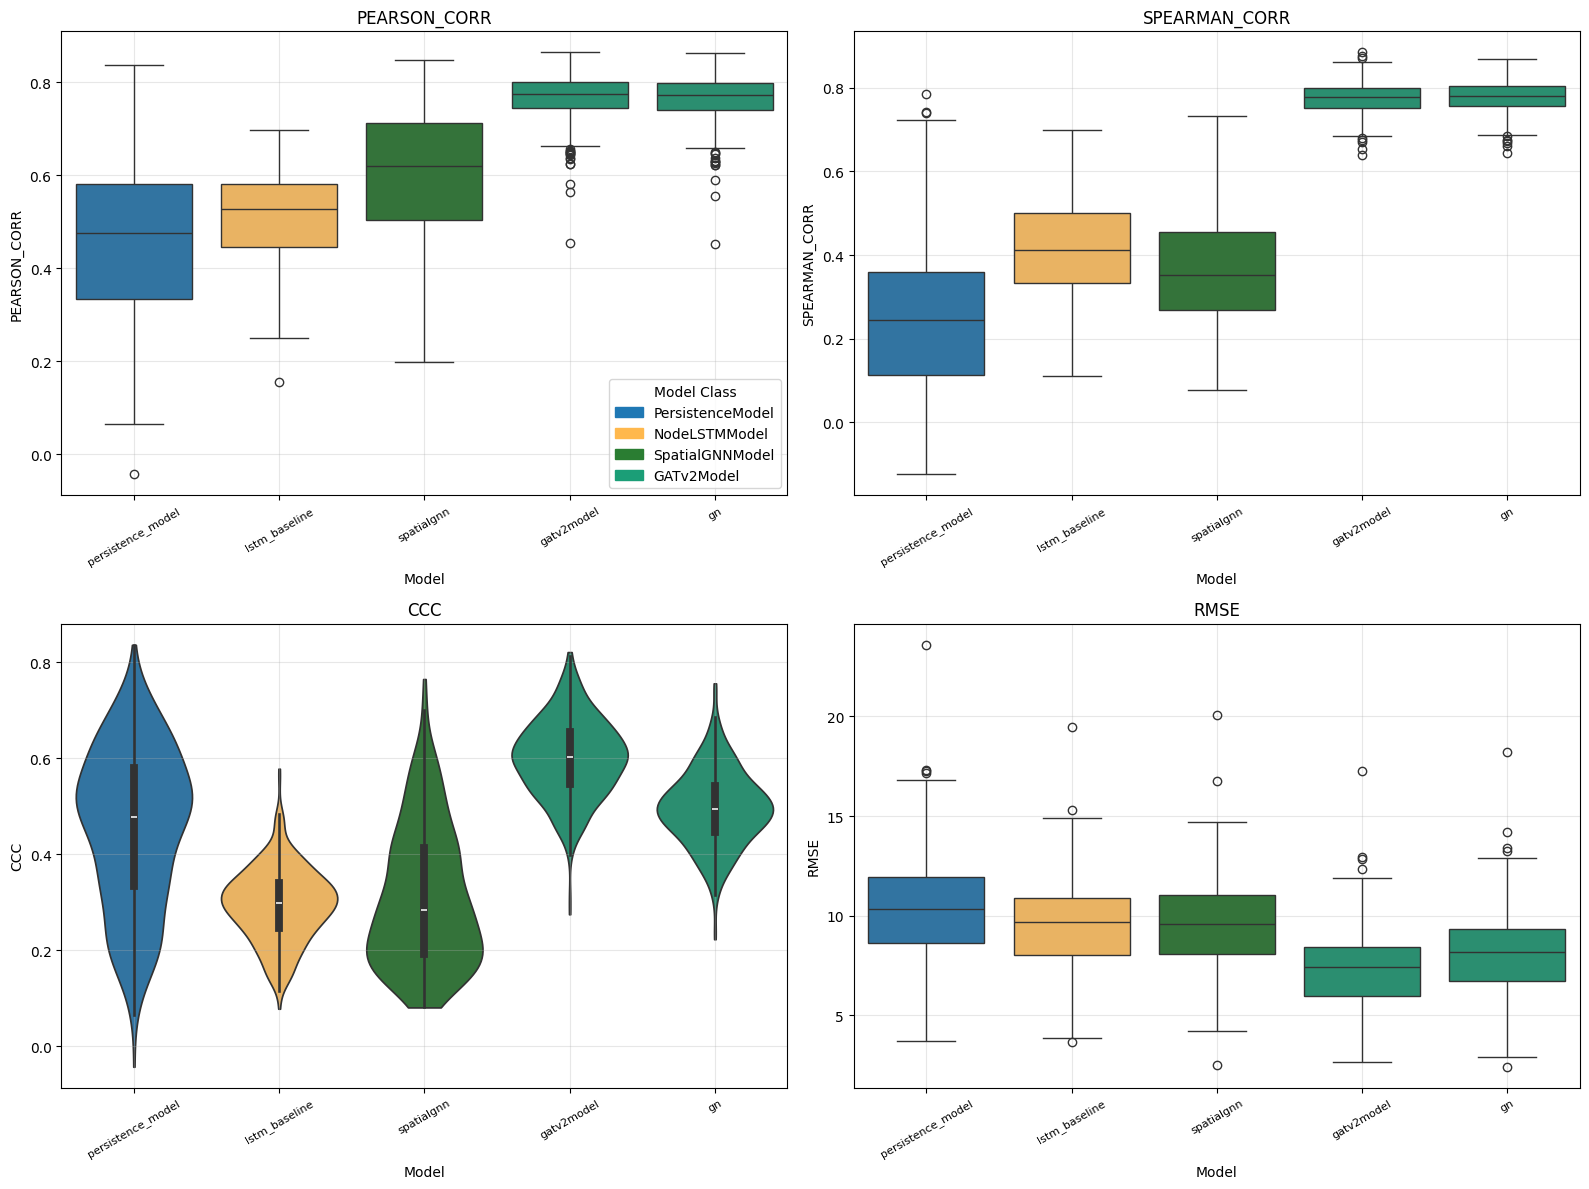

In [13]:
from src.evaluation import Evaluator

e = Evaluator([ps, lstm, gcn, gat, gat2]).add_evaluation()
e.plotter.plot_metric_compilation(plot_types = ['box','box','violin','box']).show()